In [1]:
# This code simulates a single neuron of choice
#import brian2
from brian2 import *
import sys
sys.path.append('Neuron and Synapse Models')
from NeuronModels import *
import matplotlib.pyplot as plt

In [2]:
# Parameters
Vth = -48*mV
V_reset = -80*mV

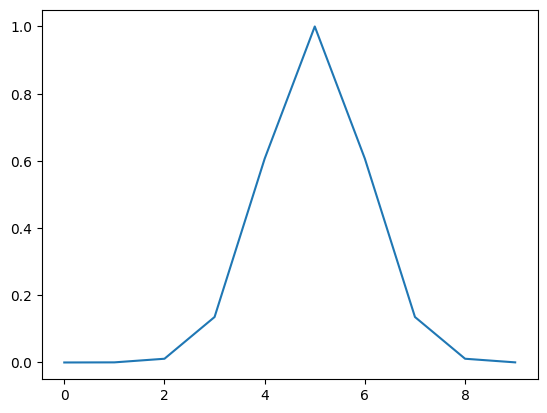

In [3]:
# Creating a fake input
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

input_weights = gaussian(np.arange(0,10),5,1) #input object

plt.plot(input_weights)

In [4]:
#FEDEs CODE

class Gaussian_Input_Generator:
    def __init__(self,
                 n,
                 m=0,
                 mu=0,
                 sigma=1,
                 noise=False,):
        
        self.n=n
        self.m=m  #amplitude
        self.mu=mu #peak position (preferred direction of the corresponding neuron (theta in gradi))
        self.sigma=sigma #refers to the certainty of the cue
        self.noise=noise
        self.x=array([360.0/n*i for i in range(n)])
    
    def generate_cue(self):
        
        wraps = np.arange(-5, 6)
        y=self.m * np.sum(np.exp(-0.5 * ((self.x[:,None]-self.mu+wraps*360) /self.sigma)**2),axis=1)
        # wrapped_gaussian=np.sum(exp(-0.5 * ((self.x[:,None]-self.mu+wraps*360) / self.sigma)**2),axis=1)
        # normalization=1/(self.sigma*(2*pi)**0.5)

        # gaussian=self.m*wrapped_gaussian*normalization

        if self.noise:
            y=self.add_noise(y)

        return y

    def add_noise(self,I):
        I_noisy=I+normal(0,1,len(self.x))*2e-2
        return I_noisy

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
SpikeGeneratorGroup(10, indices=<length 1 array>, times=<length 1 array>)


WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


<input_synapses.W_input: array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]) * mvolt>
<Network at time t=0. s, containing objects: SynapticPathway(clock=Clock(dt=2. * msecond, name='excitatory_neurons_clock'), when=synapses, order=-1, name='ring2inh_synapses_pre'), <SpikeMonitor, recording from 'spike_excitatory'>, Thresholder(clock=Clock(dt=2. * msecond, name='inhibitiry_neurons_clock'), when=thresholds, order=0, name='inhibitiry_neurons_spike_thresholder'), Resetter(clock=Clock(dt=2. * msecond, name='inhibitiry_neurons_clock'), when=resets, order=0, name='inhibitiry_neurons_spike_resetter'), Synapses(clock=Clock(dt=2. * msecond, name='ring2rings_synapses_clock'), when=start, order=0, name='ring2rings_synapses'), <StateMonitor, recording ['V'] from 'inhibitiry_neurons'>, Synapses(clock=Clock(dt=2. * msecond, name='inh2inh_synapses_clock'), when=start, order=0, name='inh2inh_synapses'), SynapticPathway(clock=Clock(dt=2. * msecond, name='inhibitiry_neurons_clock'), when=synapses, order=-1, 

WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'V_post = W_inh2inh'
 [brian2.codegen.generators.base]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'V_post = W_inh2ring'
 [brian2.codegen.generators.base]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'V_post = W_ring2inh'
 [brian2.codegen.generators.base]


(<StateMonitor, recording ['V'] from 'excitatory_neurons'>,
 <SpikeMonitor, recording from 'spike_excitatory'>,
 <StateMonitor, recording ['V'] from 'inhibitiry_neurons'>,
 <SpikeMonitor, recording from 'spike_inhibitory'>)

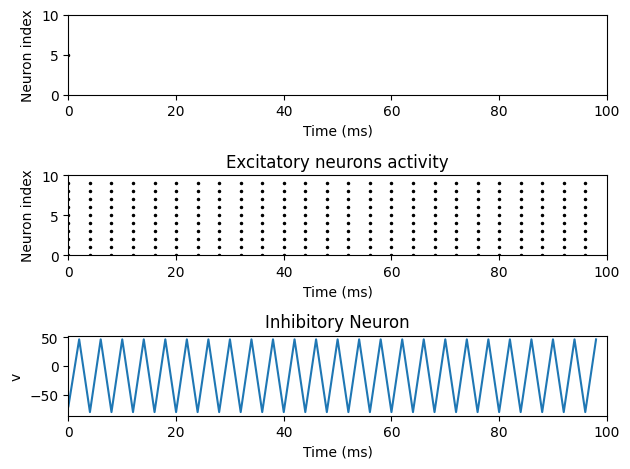

In [7]:
from ring_attractor import RingAttractor
import numpy as np

# Creating a fake input
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

def simulate(duration, plot_states=False): #, input_weights=None, nput_gen=0, ):
        

        #The input generated consists of all the 10 spikes to fire in parallel at t = 0 s
        input_weights = np.zeros(10) #0.00*gaussian(np.arange(0,10),5,1) #input object 
        input_weights[5] = 1
        print(input_weights)
        input_gen = SpikeGeneratorGroup(
            N=10, indices = [5], times=np.zeros(1)*ms, dt=2*ms
        )
        print(input_gen)

        obj_network = RingAttractor(N=10)

        connecting_input = Synapses(input_gen, obj_network.excitatory_neurons, model='W_input : volt', name="input_synapses")
        connecting_input.connect(condition="i==j")
        connecting_input.W_input[:] = input_weights.flatten() * mV
        print(connecting_input.W_input)

        spike_monitor_input = SpikeMonitor(input_gen, name="spike_input")
        network = obj_network.net
        print(network)
        network.add(input_gen)
        network.add(connecting_input)
        network.add(spike_monitor_input)

        """
        state_monitors = StateMonitor(obj_network.excitatory_neurons, "V", record=True, name="state_excitatory")
        spike_monitors = SpikeMonitor(obj_network.excitatory_neurons, name="spike_excitatory")
        inhibitory_state_monitors = StateMonitor(obj_network.inhibit_neuron, "V", record=True, name="state_inhibitory")
        inhibitory_spike_monitors = SpikeMonitor(obj_network.inhibit_neuron, name="spike_inhibitory")
        monitors = [spike_monitor_input, state_monitors, inhibitory_state_monitors, spike_monitors, inhibitory_spike_monitors]


        network.add(monitors) #if I don`t add this nothing is really happening`
        """
        network.run(duration) #HERE ERROR

        if plot_states:
            fig, ax = plt.subplots(3,1)
            ax[0].plot(spike_monitor_input.t/ms, spike_monitor_input.i, '.k', ms=3)
            ax[0].set_xlim(0, duration/ms)
            ax[0].set_ylim(0, obj_network.N)
            ax[0].set_xlabel('Time (ms)')
            ax[0].set_ylabel('Neuron index')

            ax[1].plot(obj_network.spike_monitors.t/ms, obj_network.spike_monitors.i, '.k', ms=3)
            ax[1].set_xlim(0, duration/ms)
            ax[1].set_ylim(0, obj_network.N)
            ax[1].set_xlabel('Time (ms)')
            ax[1].set_ylabel('Neuron index')
            ax[1].set_title("Excitatory neurons activity")

            ax[2].plot(obj_network.inhibitory_state_monitors.t/ms, obj_network.inhibitory_state_monitors.V[0]/mV)
            ax[2].set_xlabel('Time (ms)')
            ax[2].set_ylabel('v')
            ax[2].set_xlim([0, duration/ms])
            ax[2].set_title('Inhibitory Neuron')

            plt.tight_layout()

        return obj_network.state_monitors, obj_network.spike_monitors, obj_network.inhibitory_state_monitors, obj_network.inhibitory_spike_monitors
    

#not caring anymore about the definition of the connectivity related to the 
# gaussian distribution in the inputs
#Trying running it without input (no spike, anything)
simulate(duration=100*ms, plot_states=True) #, input_gen=input_gen, input_weights=input_weights)

#something is not working